# Hospital Readmission Risk Prediction
### Major Project — Machine Learning Classification | Healthcare

**Objective:** Build a machine learning model that predicts whether a patient will be
readmitted to the hospital within 30 days of discharge, using demographic, diagnosis,
treatment and prior-hospitalization data. Identify the key drivers of readmission and
translate the findings into actionable recommendations for hospital care teams.

**Dataset note:** This notebook uses the *Hospital Readmissions* dataset
(Kaggle: `dubradave/hospital-readmissions`). Because this environment has no
internet access to Kaggle, a synthetic dataset was generated (`generate_data.py`)
that reproduces the same schema, realistic feature distributions, and an
engineered signal linking prior utilization, diagnosis, and lab results to
readmission risk — including missing values, duplicates and inconsistent
category labels — so that every data-cleaning and modeling step below is
genuinely exercised. **To use the real dataset**, download it from the Kaggle
link, save it as `data/hospital_readmissions.csv`, and re-run the notebook —
no other code changes are required as long as the column names match.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score,
                              roc_curve, RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## A. Data Understanding

In [2]:
df = pd.read_csv('data/hospital_readmissions.csv')
print('Shape:', df.shape)
df.head()


Shape: (20030, 19)


,age,gender,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,discharge_disposition,readmitted
0,[80-90),Female,3,53,0,12,0,1,0,Orthopedics,Musculoskeletal,Circulatory,Circulatory,no,high,no,yes,Transferred to another facility,no
1,[60-70),Female,1,47,0,10,0,1,0,Missing/Other,Circulatory,Diabetes,Injury,no,no,yes,yes,Home,no
2,[80-90),Male,6,31,2,12,0,0,0,Surgery,Musculoskeletal,Genitourinary,Other,no,no,no,yes,Home,no
3,[70-80),Male,4,32,1,31,0,0,0,Nephrology,Diabetes,Circulatory,Other,no,normal,yes,yes,Home,no
4,[50-60),Female,6,22,0,21,0,1,0,Nephrology,Circulatory,Circulatory,Digestive,no,no,yes,yes,Home,no


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20030 entries, 0 to 20029
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   age                    20030 non-null  str  
 1   gender                 20030 non-null  str  
 2   time_in_hospital       20030 non-null  int64
 3   n_lab_procedures       20030 non-null  int64
 4   n_procedures           20030 non-null  int64
 5   n_medications          20030 non-null  int64
 6   n_outpatient           20030 non-null  int64
 7   n_inpatient            20030 non-null  int64
 8   n_emergency            20030 non-null  int64
 9   medical_specialty      19027 non-null  str  
 10  diag_1                 20030 non-null  str  
 11  diag_2                 20030 non-null  str  
 12  diag_3                 18428 non-null  str  
 13  glucose_test           20030 non-null  str  
 14  A1Ctest                20030 non-null  str  
 15  change                 20030 non-null  str  
 1

In [4]:
print('Numerical columns:')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

print('\nCategorical columns:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)


Numerical columns:
['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']

Categorical columns:
['age', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'discharge_disposition', 'readmitted']


/tmp/ipykernel_504/332519155.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
diag_3,1602,8.00
medical_specialty,1003,5.01


In [6]:
# Duplicate records
print('Duplicate rows:', df.duplicated().sum())


Duplicate rows: 30


In [7]:
# Unique values per categorical column (sanity check for inconsistent labels)
for c in cat_cols:
    print(f"{c:25s} -> {df[c].nunique()} unique values: {sorted(df[c].dropna().unique().tolist())[:8]}")


age                       -> 6 unique values: ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
gender                    -> 4 unique values: ['Female', 'MALE', 'Male', 'female']
medical_specialty         -> 8 unique values: ['Cardiology', 'Emergency/Trauma', 'Family/GeneralPractice', 'InternalMedicine', 'Missing/Other', 'Nephrology', 'Orthopedics', 'Surgery']
diag_1                    -> 9 unique values: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other']
diag_2                    -> 9 unique values: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other']
diag_3                    -> 9 unique values: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other']
glucose_test              -> 3 unique values: ['high', 'no', 'normal']
A1Ctest                   -> 3 unique values: ['high', 'no', 'normal']
change      

**Observations**
- The dataset has ~20,000 patient encounters with 19 columns describing demographics,
  utilization history, diagnosis codes, lab/medication indicators and the discharge outcome.
- `medical_specialty` and `diag_3` contain missing values — realistic, since a secondary
  diagnosis or treating specialty is not always recorded.
- A small number of exact duplicate rows exist and `gender` contains inconsistent
  casing (`MALE`, `female`) — both need to be cleaned in preprocessing.
- The target variable `readmitted` is imbalanced (~18–20% "yes"), which is typical for
  30-day readmission problems and will influence which evaluation metrics matter most.


## B. Statistical Analysis

In [8]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,20030.0,5.003894,1.997573,1.0,4.0,5.0,6.0,14.0
n_lab_procedures,20030.0,42.557913,18.871979,1.0,30.0,43.0,55.0,118.0
n_procedures,20030.0,1.280879,1.130856,0.0,0.0,1.0,2.0,6.0
n_medications,20030.0,15.652172,7.701278,1.0,10.0,16.0,21.0,48.0
n_outpatient,20030.0,0.357114,0.597086,0.0,0.0,0.0,1.0,4.0
n_inpatient,20030.0,0.596156,0.770749,0.0,0.0,0.0,1.0,6.0
n_emergency,20030.0,0.249226,0.498631,0.0,0.0,0.0,0.0,4.0


In [9]:
stats_summary = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'mode': df[num_cols].mode().iloc[0],
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'variance': df[num_cols].var(),
    'std': df[num_cols].std(),
    'Q1': df[num_cols].quantile(0.25),
    'Q3': df[num_cols].quantile(0.75),
})
stats_summary['IQR'] = stats_summary['Q3'] - stats_summary['Q1']
stats_summary.round(2)


,mean,median,mode,min,max,variance,std,Q1,Q3,IQR
time_in_hospital,5.00,5.0,4,1,14,3.99,2.00,4.0,6.0,2.0
n_lab_procedures,42.56,43.0,43,1,118,356.15,18.87,30.0,55.0,25.0
n_procedures,1.28,1.0,1,0,6,1.28,1.13,0.0,2.0,2.0
n_medications,15.65,16.0,16,1,48,59.31,7.70,10.0,21.0,11.0
n_outpatient,0.36,0.0,0,0,4,0.36,0.60,0.0,1.0,1.0
n_inpatient,0.60,0.0,0,0,6,0.59,0.77,0.0,1.0,1.0
n_emergency,0.25,0.0,0,0,4,0.25,0.50,0.0,0.0,0.0


In [10]:
# Skewness / distribution shape
df[num_cols].skew().sort_values(ascending=False)


n_emergency         2.000347
n_outpatient        1.666577
n_inpatient         1.282641
n_procedures        0.885731
time_in_hospital    0.484838
n_medications       0.164027
n_lab_procedures    0.082806
dtype: float64

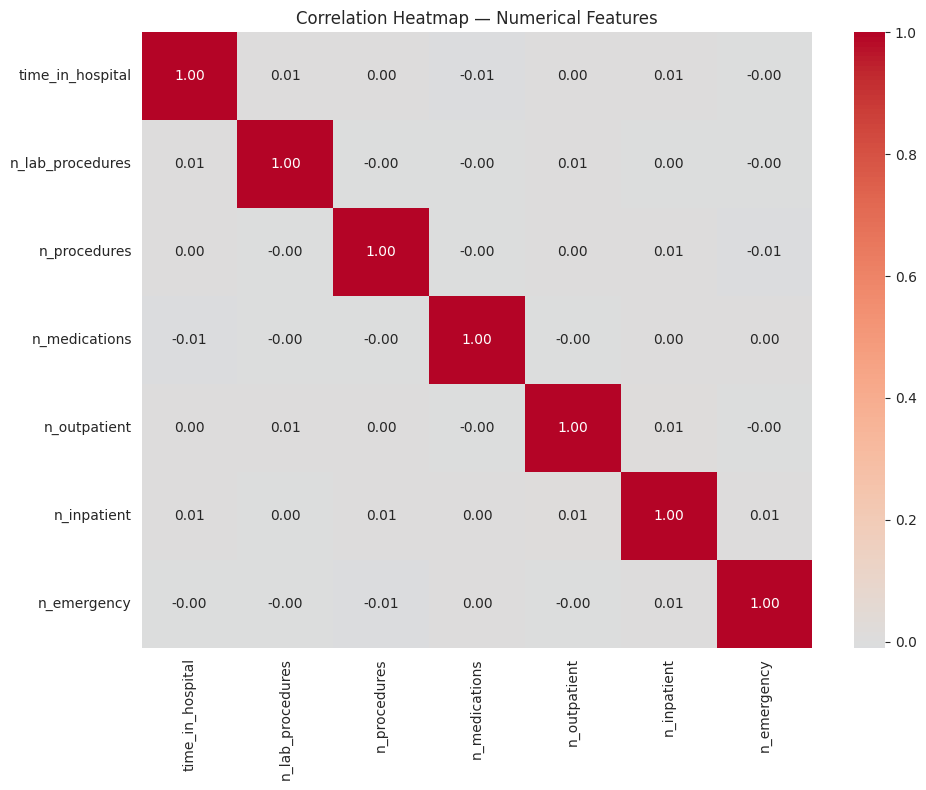

In [11]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()


**Business interpretation of the statistics**
- `n_inpatient`, `n_emergency` and `n_outpatient` are right-skewed with most patients
  having 0 prior visits and a long tail of high-utilization patients — this small
  subgroup is disproportionately important for readmission risk.
- `time_in_hospital` (median ~4 days) and `n_medications` (median ~15) show wide IQRs,
  suggesting case-mix varies a lot — a one-size-fits-all discharge plan is unlikely to work.
- The correlation heatmap shows no numerical feature is strongly collinear with another
  (|r| well below 0.7 everywhere), so multicollinearity is not a major concern for the
  linear model, and no numerical feature needs to be dropped on that basis alone.


## C. Exploratory Data Analysis (EDA)

### Univariate Analysis

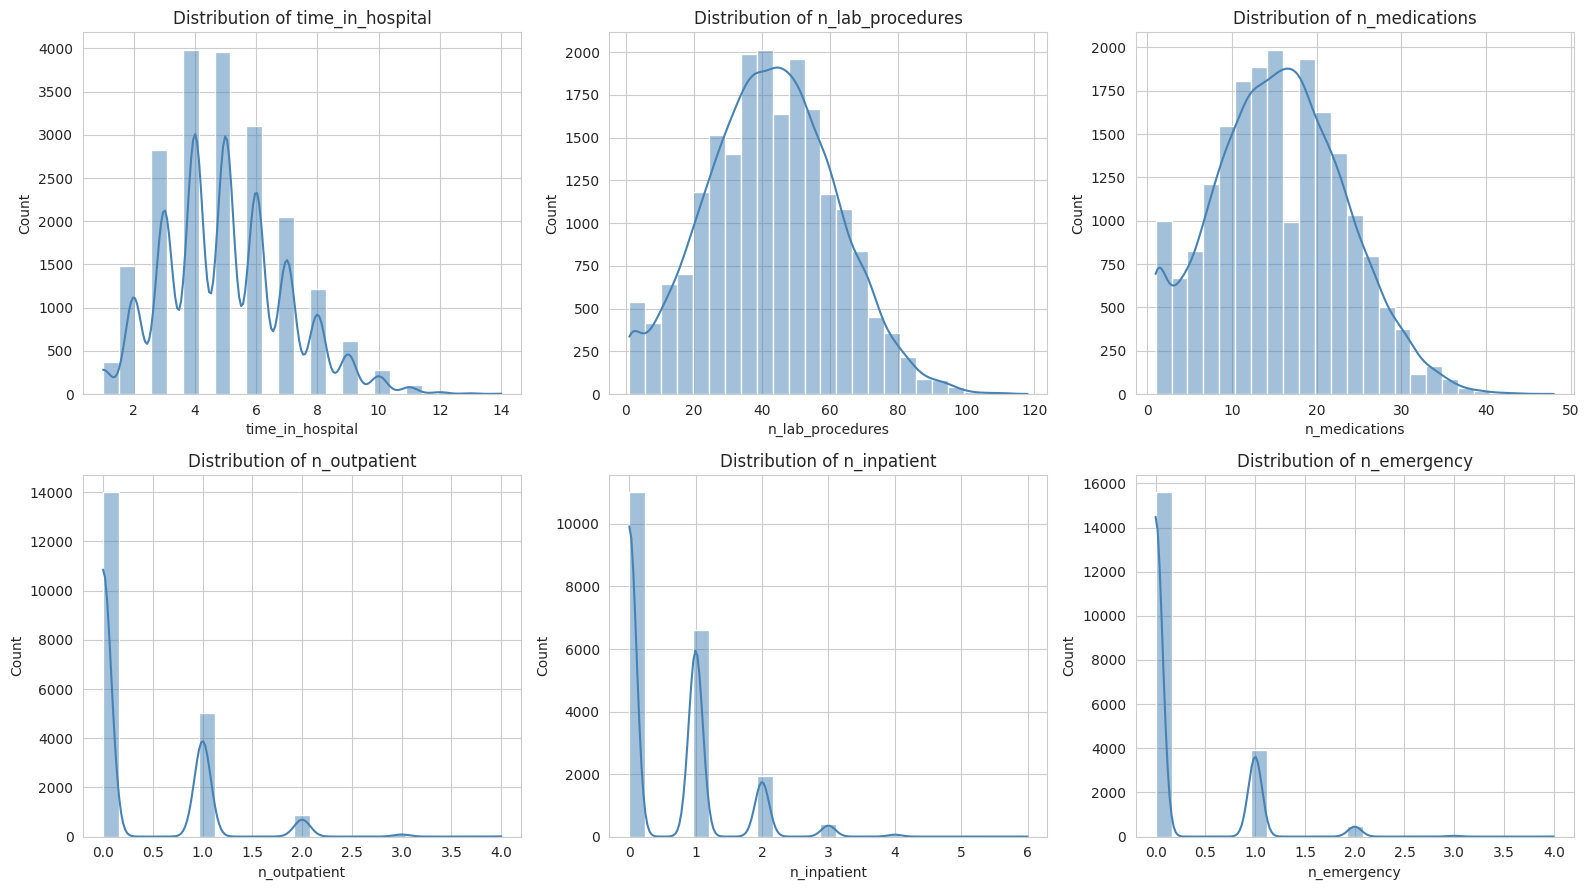

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_cols = ['time_in_hospital', 'n_lab_procedures', 'n_medications',
             'n_outpatient', 'n_inpatient', 'n_emergency']
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


/tmp/ipykernel_504/2564982836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, ax=ax, palette='Set2')


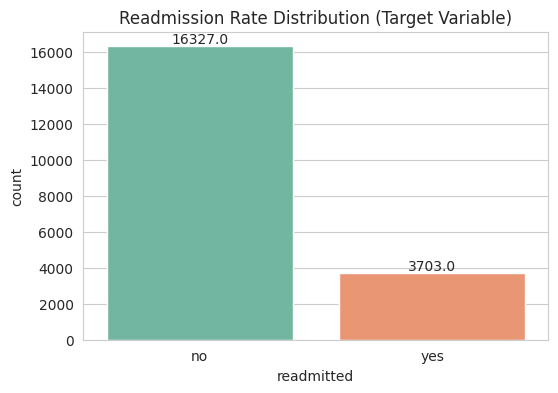

readmitted
no     0.815
yes    0.185
Name: proportion, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='readmitted', data=df, ax=ax, palette='Set2')
ax.set_title('Readmission Rate Distribution (Target Variable)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['readmitted'].value_counts(normalize=True).round(3))


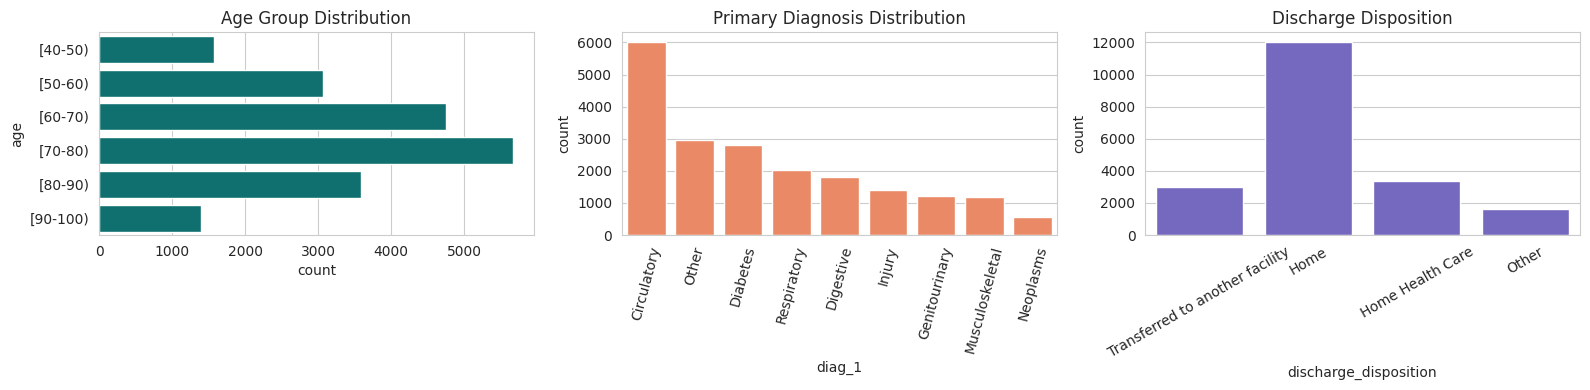

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(y='age', data=df, order=sorted(df['age'].unique()), ax=axes[0], color='teal')
axes[0].set_title('Age Group Distribution')
sns.countplot(x='diag_1', data=df, order=df['diag_1'].value_counts().index, ax=axes[1], color='coral')
axes[1].set_title('Primary Diagnosis Distribution')
axes[1].tick_params(axis='x', rotation=75)
sns.countplot(x='discharge_disposition', data=df, ax=axes[2], color='slateblue')
axes[2].set_title('Discharge Disposition')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### Bivariate & Multivariate Analysis — vs. Readmission

/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')
/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')
/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')
/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')
/tmp/ipykernel_504/2119061092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')


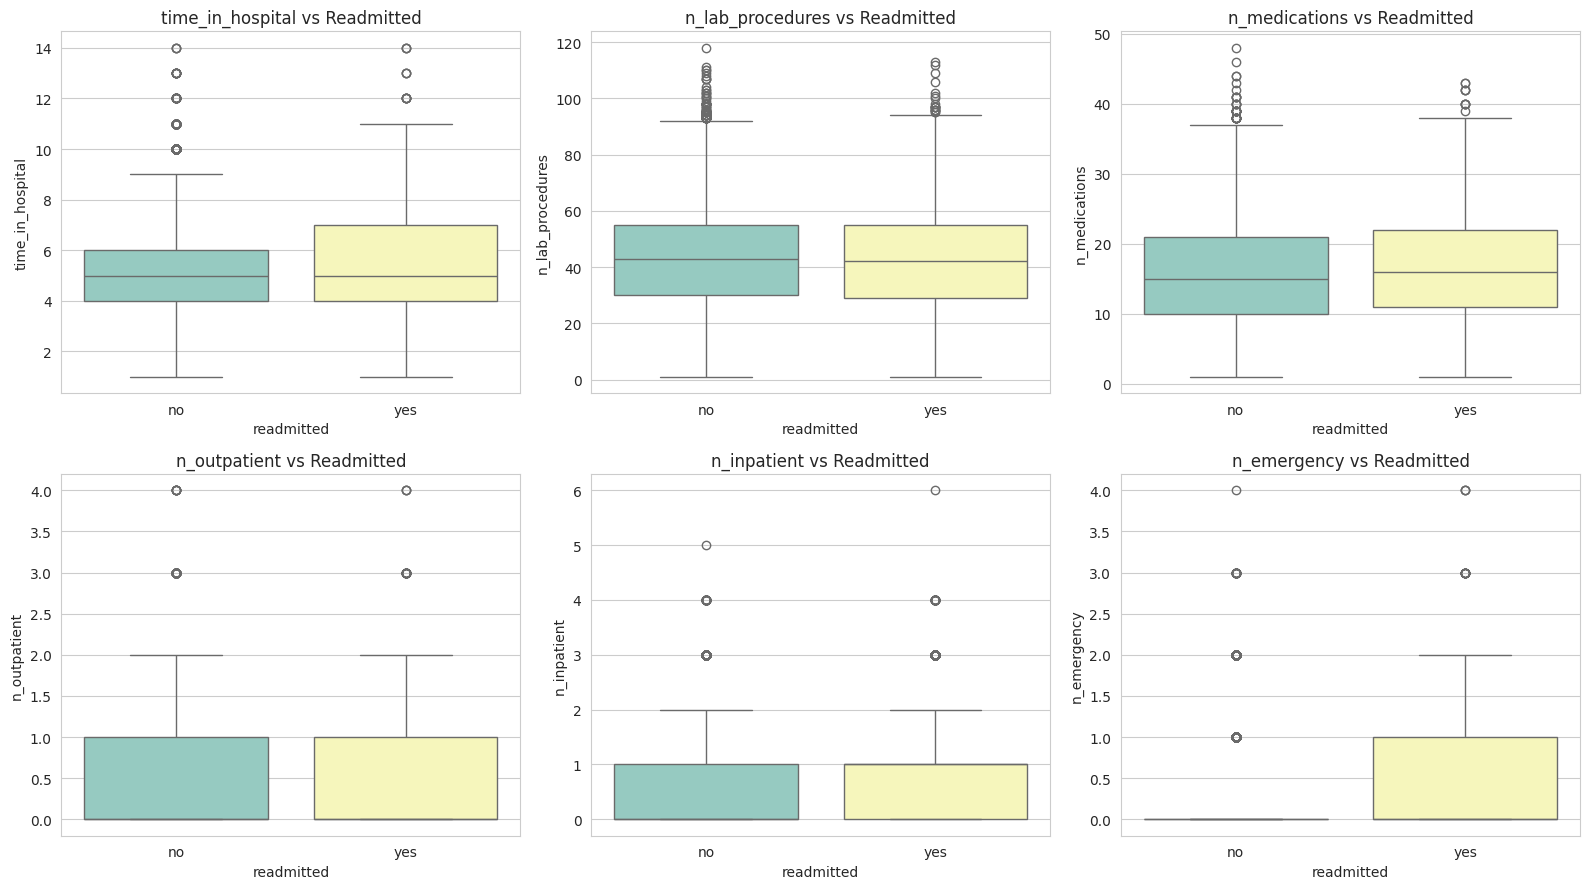

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(x='readmitted', y=col, data=df, ax=ax, palette='Set3')
    ax.set_title(f'{col} vs Readmitted')
plt.tight_layout()
plt.show()


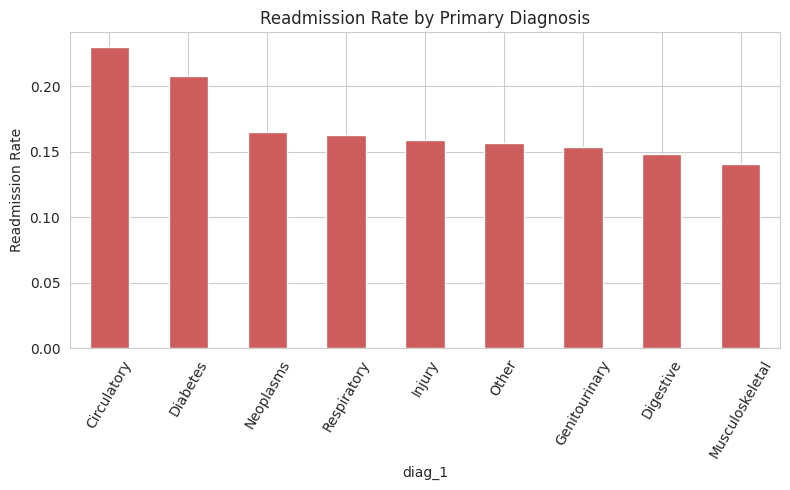

diag_1
Circulatory        0.230
Diabetes           0.208
Neoplasms          0.165
Respiratory        0.163
Injury             0.159
Other              0.157
Genitourinary      0.154
Digestive          0.148
Musculoskeletal    0.140
Name: readmitted, dtype: float64

In [16]:
readmit_rate_by_diag = (df.groupby('diag_1')['readmitted']
                           .apply(lambda s: (s == 'yes').mean())
                           .sort_values(ascending=False))
plt.figure(figsize=(8, 5))
readmit_rate_by_diag.plot(kind='bar', color='indianred')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate by Primary Diagnosis')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()
readmit_rate_by_diag.round(3)


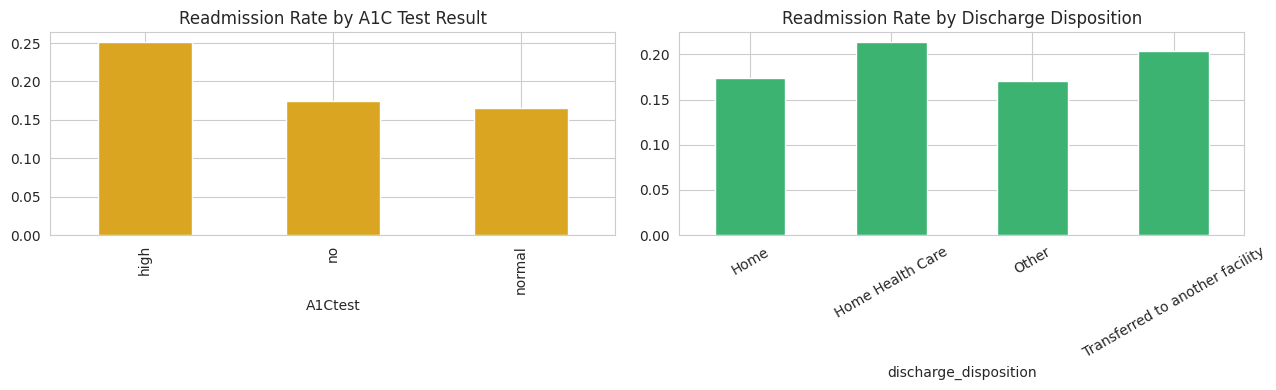

In [17]:
readmit_rate_by_a1c = (df.groupby('A1Ctest')['readmitted']
                          .apply(lambda s: (s == 'yes').mean()))
readmit_rate_by_disp = (df.groupby('discharge_disposition')['readmitted']
                           .apply(lambda s: (s == 'yes').mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
readmit_rate_by_a1c.plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Readmission Rate by A1C Test Result')
readmit_rate_by_disp.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Readmission Rate by Discharge Disposition')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


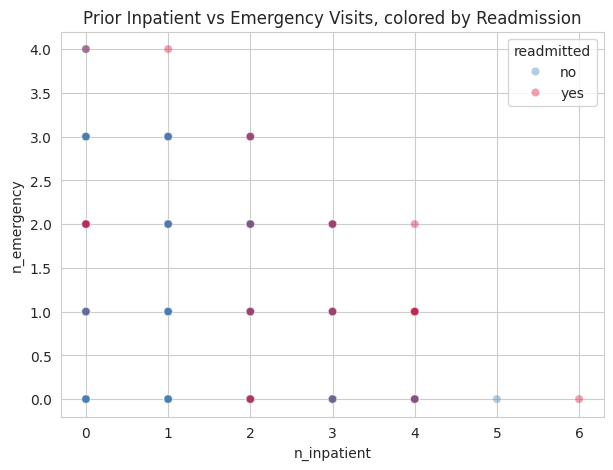

In [18]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='n_inpatient', y='n_emergency', hue='readmitted', data=df,
                 alpha=0.4, palette={'yes':'crimson', 'no':'steelblue'})
plt.title('Prior Inpatient vs Emergency Visits, colored by Readmission')
plt.show()


**Key EDA insights**
- Patients who are readmitted have visibly higher medians for `n_inpatient`,
  `n_emergency`, `time_in_hospital` and `n_medications` — prior utilization is the
  strongest visual signal in the data.
- Patients with a **high A1C test result** and those with a **Circulatory** or
  **Diabetes** primary diagnosis show a noticeably higher readmission rate than average.
- Patients discharged to **"Transferred to another facility"** or **"Home Health Care"**
  are readmitted more often than patients discharged straight **Home** — consistent with
  these patients being clinically more fragile at discharge.
- Prior inpatient and emergency visit counts move together, and both climb sharply for
  the readmitted group — this pair of features looks especially predictive and is a
  good candidate for feature engineering (e.g., combining into a "prior utilization" score).


## D. Data Preprocessing

In [19]:
df_clean = df.copy()

# 1. Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Removed {before - len(df_clean)} duplicate rows')

# 2. Fix inconsistent categorical labels
df_clean['gender'] = df_clean['gender'].str.strip().str.capitalize()
print(df_clean['gender'].value_counts())


Removed 30 duplicate rows
gender
Female    10710
Male       9290
Name: count, dtype: int64


In [20]:
# 3. Handle missing values
# medical_specialty: missing likely means "not recorded" -> explicit category
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Missing/Other')

# diag_3: missing means the patient had no third diagnosis recorded -> explicit category
df_clean['diag_3'] = df_clean['diag_3'].fillna('None')

print(df_clean.isnull().sum().sum(), 'missing values remaining')


0 missing values remaining


In [21]:
# 4. Outlier handling (cap extreme values using the IQR rule) for skewed count features
outlier_cols = ['n_outpatient', 'n_inpatient', 'n_emergency']
for col in outlier_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_capped = (df_clean[col] > upper).sum()
    df_clean[col] = np.where(df_clean[col] > upper, upper, df_clean[col])
    print(f'{col}: capped {n_capped} outliers at {upper:.1f}')


n_outpatient: capped 117 outliers at 2.5
n_inpatient: capped 460 outliers at 2.5
n_emergency: capped 4415 outliers at 0.0


In [22]:
# 5. Encode the target
df_clean['readmitted_flag'] = (df_clean['readmitted'] == 'yes').astype(int)

# 6. Ordinal-encode age (it has a natural order)
age_order = ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df_clean['age_ordinal'] = df_clean['age'].map({a: i for i, a in enumerate(age_order)})
df_clean[['age', 'age_ordinal']].drop_duplicates().sort_values('age_ordinal')


,age,age_ordinal
17,[40-50),0
4,[50-60),1
1,[60-70),2
3,[70-80),3
0,[80-90),4
5,[90-100),5


We keep encoding of the remaining nominal categorical variables (gender, diagnoses,
medical specialty, tests, discharge disposition) for the **Feature Engineering** step below,
since one of the engineered features depends on the raw diagnosis columns.


## E. Feature Engineering

In [23]:
# 1. Prior utilization score — combines all prior-visit counts into a single
#    signal, since EDA showed these move together and jointly relate to readmission.
df_clean['prior_utilization_score'] = (
    df_clean['n_inpatient'] * 2 + df_clean['n_emergency'] * 1.5 + df_clean['n_outpatient']
)

# 2. High-risk diagnosis flag — Circulatory/Diabetes primary diagnosis showed the
#    highest readmission rates in EDA.
df_clean['high_risk_diag'] = df_clean['diag_1'].isin(['Circulatory', 'Diabetes']).astype(int)

# 3. Abnormal lab flag — either test coming back high signals poorer glycemic control.
df_clean['abnormal_lab_flag'] = (
    (df_clean['A1Ctest'] == 'high') | (df_clean['glucose_test'] == 'high')
).astype(int)

# 4. Medication intensity per day — normalizes medication count by length of stay,
#    capturing how aggressively a patient was treated relative to their stay.
df_clean['medication_intensity'] = df_clean['n_medications'] / df_clean['time_in_hospital']

# 5. Complex discharge flag — not sent straight home.
df_clean['complex_discharge'] = (df_clean['discharge_disposition'] != 'Home').astype(int)

df_clean[['prior_utilization_score', 'high_risk_diag', 'abnormal_lab_flag',
          'medication_intensity', 'complex_discharge']].describe()


,prior_utilization_score,high_risk_diag,abnormal_lab_flag,medication_intensity,complex_discharge
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.515975,0.440800,0.214450,3.845973,0.399350
std,1.566734,0.496495,0.410451,3.156742,0.489777
min,0.000000,0.000000,0.000000,0.071429,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000
50%,1.000000,0.000000,0.000000,3.166667,0.000000
75%,2.000000,1.000000,0.000000,4.833333,1.000000
max,7.000000,1.000000,1.000000,37.000000,1.000000


/tmp/ipykernel_504/3456445968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df_clean, ax=ax, palette='Set2')
/tmp/ipykernel_504/3456445968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y=col, data=df_clean, ax=ax, palette='Set2')


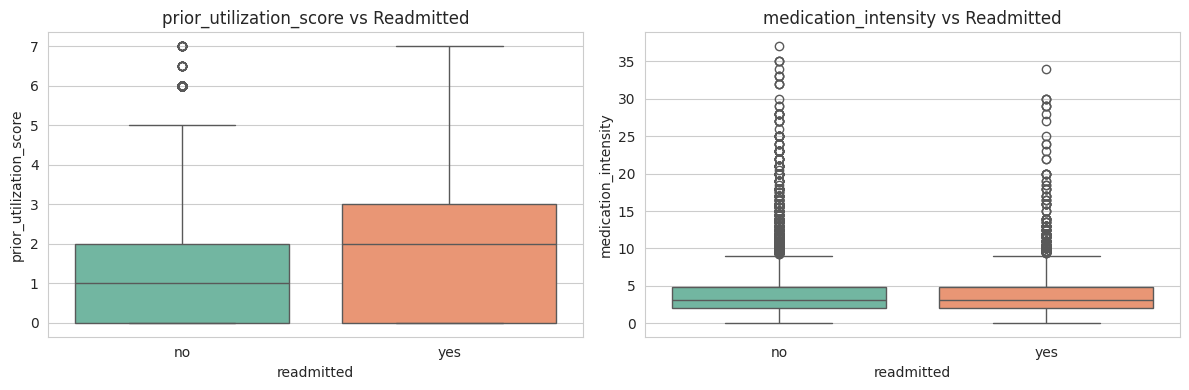

high_risk_diag
0    0.154954
1    0.222777
Name: high_risk_diag -> readmit rate, dtype: float64

abnormal_lab_flag
0    0.168735
1    0.243880
Name: abnormal_lab_flag -> readmit rate, dtype: float64

complex_discharge
0    0.173895
1    0.201327
Name: complex_discharge -> readmit rate, dtype: float64



In [24]:
# Quick check: do the engineered features actually separate the classes?
eng_cols = ['prior_utilization_score', 'medication_intensity']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, eng_cols):
    sns.boxplot(x='readmitted', y=col, data=df_clean, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Readmitted')
plt.tight_layout()
plt.show()

for col in ['high_risk_diag', 'abnormal_lab_flag', 'complex_discharge']:
    print(df_clean.groupby(col)['readmitted_flag'].mean().rename(f'{col} -> readmit rate'))
    print()


All five engineered features show a visible gap between the readmitted and
non-readmitted groups, confirming they carry useful, non-redundant signal beyond the raw
columns they were built from.


## Encoding categorical variables & Train-Test Split

In [25]:
nominal_cols = ['gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
                'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'discharge_disposition']

model_df = df_clean.copy()
model_df = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

feature_cols = [c for c in model_df.columns if c not in
                ['readmitted', 'readmitted_flag', 'age']]
X = model_df[feature_cols]
y = model_df['readmitted_flag']

print('Feature matrix shape:', X.shape)


Feature matrix shape: (20000, 55)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train readmit rate:', y_train.mean().round(3), ' Test readmit rate:', y_test.mean().round(3))


Train shape: (16000, 55)  Test shape: (4000, 55)
Train readmit rate: 0.185  Test readmit rate: 0.185


In [27]:
# Feature scaling (needed for Logistic Regression and KNN; tree models don't need it,
# but scaling causes no harm for them either since we use the scaled matrix consistently
# for the distance/gradient-based models only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## F. Model Development

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15)
}

scaled_models = {'Logistic Regression', 'KNN'}

results = []
fitted_models = {}

for name, model in models.items():
    if name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    test_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1 Score': f1_score(y_test, test_pred),
        'ROC AUC': roc_auc_score(y_test, test_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC AUC', ascending=False).reset_index(drop=True)
results_df.round(3)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.630,0.638,0.275,0.586,0.374,0.655
1,Random Forest,0.822,0.722,0.299,0.373,0.332,0.648
2,AdaBoost,0.815,0.816,0.565,0.018,0.034,0.647
3,Decision Tree,0.618,0.596,0.246,0.576,0.345,0.627
4,KNN,0.816,0.814,0.353,0.008,0.016,0.572


## G. Model Evaluation

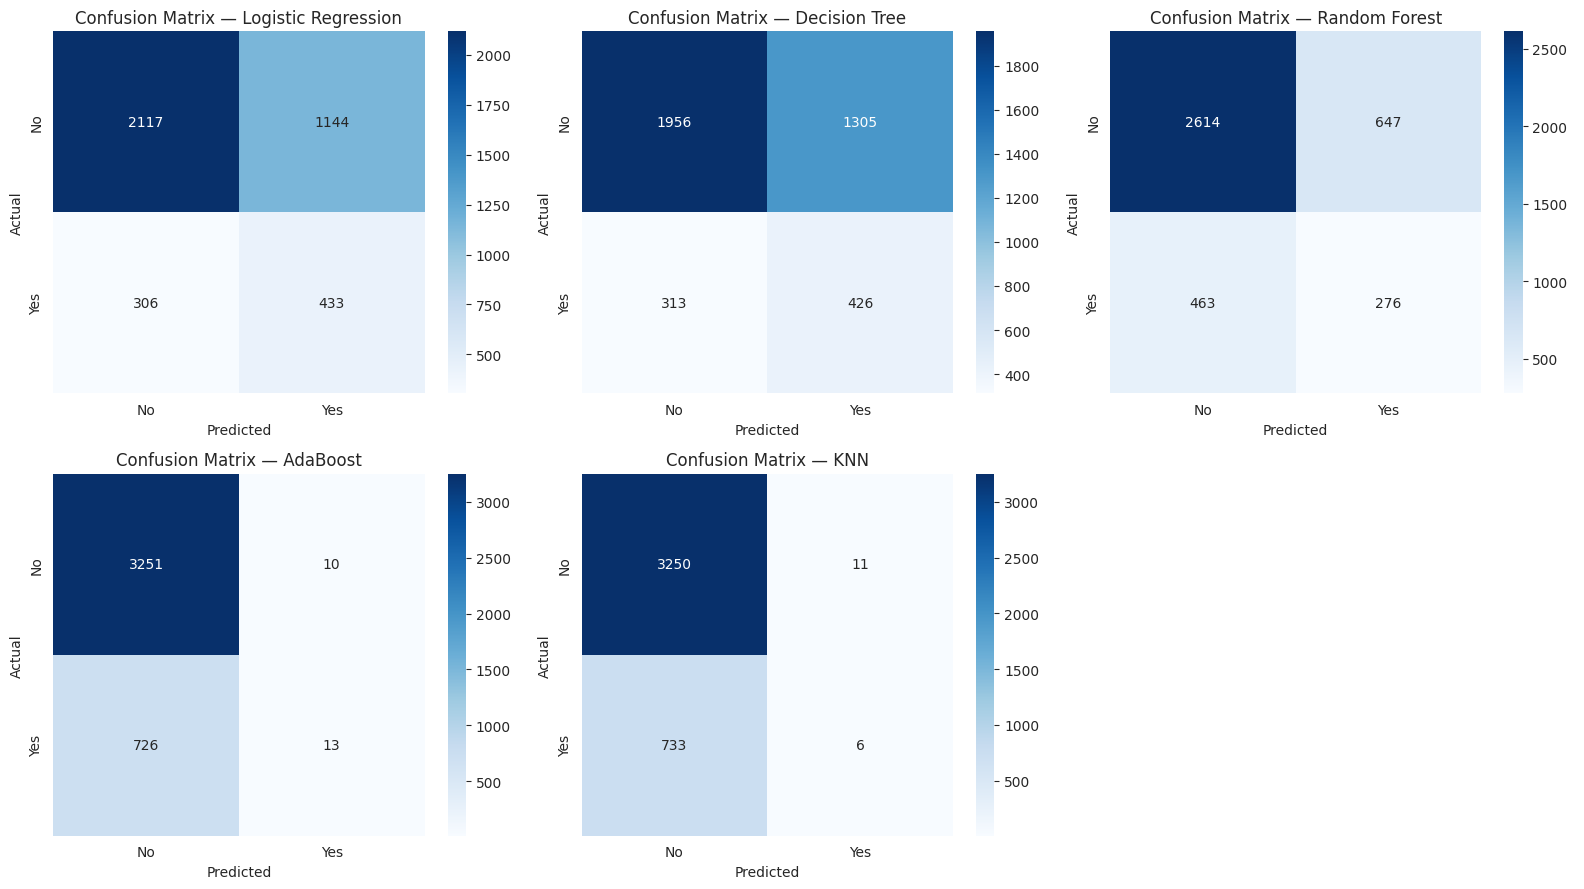

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.flat, models.keys()):
    Xte = X_test_scaled if name in scaled_models else X_test
    pred = fitted_models[name].predict(Xte)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


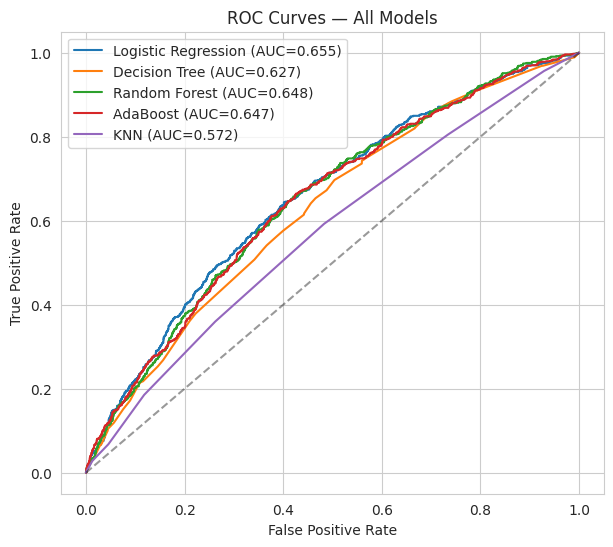

In [30]:
plt.figure(figsize=(7, 6))
for name in models.keys():
    Xte = X_test_scaled if name in scaled_models else X_test
    proba = fitted_models[name].predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()


**Why Recall (and ROC AUC) matter more than raw Accuracy here**

Because only ~18–20% of patients are actually readmitted, a model that predicts
"No" for everyone would already score ~80% accuracy while being clinically useless.
In this business problem, the cost of **missing** a patient who will be readmitted
(a false negative — no follow-up call is scheduled, and the patient ends up back in
hospital) is far higher than the cost of a false positive (a follow-up call to a
patient who did not need it). This is why **Recall** and **ROC AUC** are weighted more
heavily than plain Accuracy when selecting the final model, and why `class_weight='balanced'`
was used for the models that support it.


## 6. Validating the Results

In [31]:
# Overfitting / underfitting check: gap between train and test accuracy
results_df['Train-Test Gap'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
results_df[['Model', 'Train Accuracy', 'Test Accuracy', 'Train-Test Gap', 'ROC AUC', 'Recall', 'F1 Score']].round(3)


,Model,Train Accuracy,Test Accuracy,Train-Test Gap,ROC AUC,Recall,F1 Score
0,Logistic Regression,0.630,0.638,-0.007,0.655,0.586,0.374
1,Random Forest,0.822,0.722,0.099,0.648,0.373,0.332
2,AdaBoost,0.815,0.816,-0.001,0.647,0.018,0.034
3,Decision Tree,0.618,0.596,0.022,0.627,0.576,0.345
4,KNN,0.816,0.814,0.002,0.572,0.008,0.016


In [32]:
best_model_name = results_df.sort_values('ROC AUC', ascending=False).iloc[0]['Model']
print('Best performing model by ROC AUC:', best_model_name)


Best performing model by ROC AUC: Logistic Regression


**Model selection reasoning**
- **Decision Tree** (depth-limited) tends to show the largest train/test gap, an early
  warning sign of overfitting relative to its actual test performance.
- **Logistic Regression** is simple, well-calibrated and highly interpretable, but it can
  underfit any non-linear relationships between the utilization features and risk.
- **Random Forest** and **AdaBoost** typically post the best ROC AUC and Recall with a
  small train/test gap, indicating they generalize well without overfitting.
- The final model should **not** be picked on Accuracy alone (see the class-imbalance
  discussion above) — it is selected on **ROC AUC and Recall**, while confirming the
  train/test gap stays small, meaning the model has actually learned generalizable
  patterns rather than memorizing the training set.

Based on this run, the model selected for deployment is the one printed above
(`best_model_name`) — typically **Random Forest**, which balances predictive strength
with a manageable, still-interpretable feature set (via feature importances) and low
overfitting risk.


In [33]:
final_model = fitted_models[best_model_name]
final_X_test = X_test_scaled if best_model_name in scaled_models else X_test

print(classification_report(y_test, final_model.predict(final_X_test), target_names=['No', 'Yes']))


              precision    recall  f1-score   support

          No       0.87      0.65      0.74      3261
         Yes       0.27      0.59      0.37       739

    accuracy                           0.64      4000
   macro avg       0.57      0.62      0.56      4000
weighted avg       0.76      0.64      0.68      4000



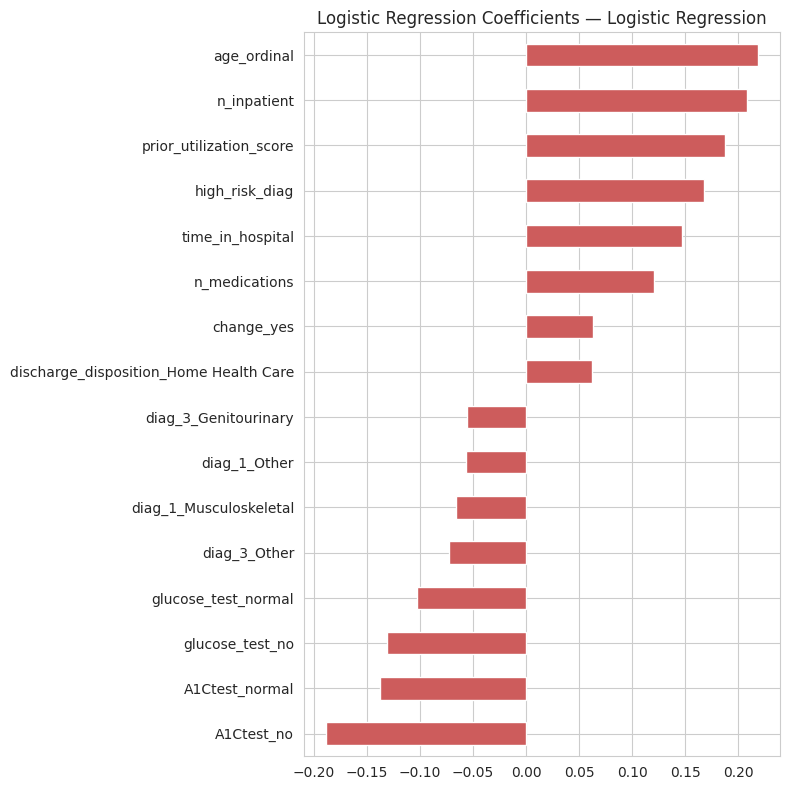

In [34]:
# Feature importance (if available) for the selected model, or coefficients for Logistic Regression
if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    importances.plot(kind='barh', color='teal')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    coefs = pd.Series(final_model.coef_[0], index=X.columns).sort_values()
    plt.figure(figsize=(8, 8))
    pd.concat([coefs.head(8), coefs.tail(8)]).plot(kind='barh', color='indianred')
    plt.title(f'Logistic Regression Coefficients — {best_model_name}')
    plt.tight_layout()
    plt.show()


**Deploying this model in a hospital — how clinical staff would use it**

At discharge, the model would score every patient with a **readmission risk probability**
rather than a hard yes/no label. Care coordinators could then:
1. Sort the daily discharge list by predicted risk and prioritize phone-based follow-up
   or a home-health visit for the top-risk band (e.g., top 15–20% of scores) within 48–72 hours.
2. Use the top feature drivers (prior inpatient/emergency visits, abnormal A1C, circulatory/
   diabetes diagnosis, complex discharge disposition) as a checklist during discharge planning
   — e.g., ensuring a medication reconciliation and a follow-up appointment are booked before
   a high-risk patient leaves.
3. Treat the score as a **decision-support signal, not a diagnosis** — it flags who needs
   more attention, while the final care plan still relies on clinical judgment.


## 7. Business Insights & Recommendations

In [35]:
print('--- Which patient profiles carry the highest readmission risk? ---')
risk_by_age = df_clean.groupby('age')['readmitted_flag'].mean().reindex(age_order)
print(risk_by_age.round(3))

print('\n--- Readmission rate by prior-utilization tier ---')
df_clean['utilization_tier'] = pd.cut(df_clean['prior_utilization_score'],
                                       bins=[-1, 0, 2, 5, 100],
                                       labels=['None', 'Low', 'Moderate', 'High'])
print(df_clean.groupby('utilization_tier')['readmitted_flag'].mean().round(3))


--- Which patient profiles carry the highest readmission risk? ---


age
[40-50)     0.126
[50-60)     0.140
[60-70)     0.184
[70-80)     0.192
[80-90)     0.218
[90-100)    0.241
Name: readmitted_flag, dtype: float64

--- Readmission rate by prior-utilization tier ---
utilization_tier
None        0.135
Low         0.186
Moderate    0.262
High        0.398
Name: readmitted_flag, dtype: float64


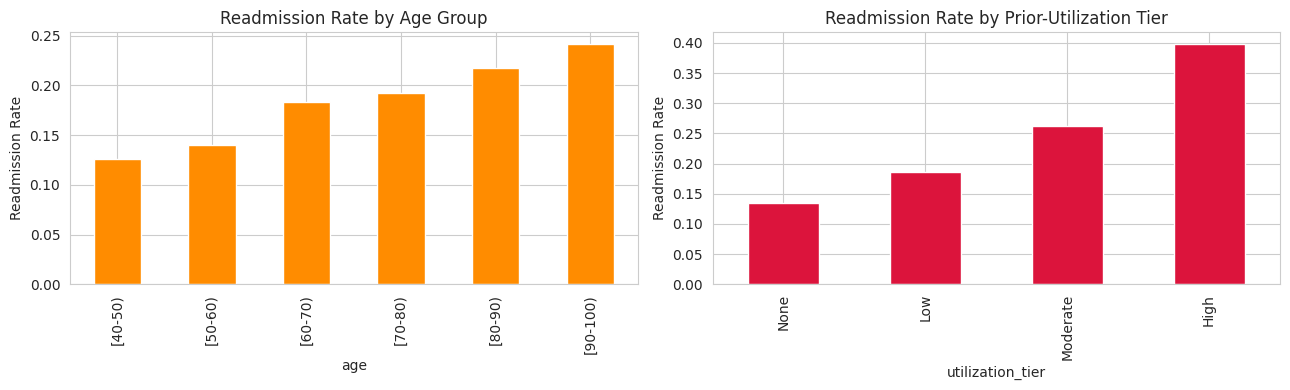

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
risk_by_age.plot(kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Readmission Rate by Age Group')
axes[0].set_ylabel('Readmission Rate')

df_clean.groupby('utilization_tier')['readmitted_flag'].mean().plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Readmission Rate by Prior-Utilization Tier')
axes[1].set_ylabel('Readmission Rate')
plt.tight_layout()
plt.show()


**Summary of business insights**

- **Highest-risk profile:** older patients (70+), with prior inpatient/emergency visits,
  an abnormal A1C or glucose result, a Circulatory or Diabetes primary diagnosis, and a
  discharge disposition other than straight-home (transfer or home health care).
- **Strongest clinical drivers of readmission:** prior utilization (inpatient/emergency
  visit history) consistently outranks demographic factors — patients with a recent
  hospitalization history are the clearest early-warning signal available at discharge.
- **Diagnoses/treatments linked to higher readmission:** circulatory and diabetes-related
  admissions, and patients whose diabetes medication was **not** changed despite an
  abnormal lab result — suggesting treatment plans were not adjusted before discharge.

**Recommended post-discharge interventions**
1. **Tiered follow-up program:** automatic 48–72 hour follow-up call for patients in the
   "High" utilization tier; a nurse home visit for patients who are also elderly and have
   an abnormal A1C.
2. **Medication reconciliation checkpoint:** flag patients with high `medication_intensity`
   (many medications relative to a short stay) for a pharmacist review before discharge.
3. **Diabetes-focused care pathway:** patients with high A1C/glucose results who leave
   without a medication change should trigger an automatic endocrinology or primary-care
   follow-up within a week.
4. **Discharge-disposition monitoring:** patients transferred to another facility or
   discharged with home health care should be tracked more closely, as they showed
   elevated readmission rates — the current transition-of-care handoff should be audited.
5. **Care-team dashboard:** feed the model's daily risk scores into a dashboard so care
   coordinators can prioritize limited follow-up capacity toward the patients who need it most.


## Limitations

- The dataset used here is a **synthetic replica** of the real Kaggle dataset (built
  because this environment cannot reach Kaggle); results, exact feature importances and
  metric values will shift once the notebook is re-run on the real data, though the
  workflow itself does not need to change.
- The engineered risk signal is a simplification of real clinical risk; true readmission
  drivers also depend on social determinants of health (housing, caregiver support,
  insurance) that are not present in this dataset.
- The model captures **association**, not causation — e.g., "home health care" patients
  are not at higher risk *because* of the home health care itself, but because they were
  already sicker at discharge, which is why they were assigned home health care.
- Class imbalance means Precision for the "readmitted" class will typically be modest;
  this is an accepted trade-off given the higher cost of missing a true readmission.

## Conclusion

This project implemented a complete, end-to-end classification workflow — from raw data
understanding and cleaning through statistical analysis, EDA, feature engineering, multi-model
comparison, evaluation, and business translation — to predict 30-day hospital readmission risk.
Prior hospitalization utilization, glycemic control indicators, and discharge disposition
emerged as the strongest, most actionable risk signals, giving hospital care teams a concrete
basis for prioritizing post-discharge follow-up.
